In [1]:
# RetailOps 360 | Demand Forecasting & Analysis
# Author: Mohammad Ali Rafique
# Dataset: Olist Brazilian E-Commerce

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
# Load core Olist datasets
orders = pd.read_csv(r'C:/path/to/olist_orders_dataset.csv')
order_items = pd.read_csv(r'C:/path/to/olist_order_items_dataset.csv')
products = pd.read_csv(r'C:/path/to/olist_products_dataset.csv')
customers = pd.read_csv(r'C:/path/to/olist_customers_dataset.csv')
payments = pd.read_csv(r'C:/path/to/olist_order_payments_dataset.csv')
category_translation = pd.read_csv(r'C:/path/to/product_category_name_translation.csv')

print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Products: {products.shape}")
print(f"Customers: {customers.shape}")
print(f"Payments: {payments.shape}")
print(f"Categories: {category_translation.shape}")

In [2]:
# Load core Olist datasets
path = r'C:\Users\Ali\Downloads\New folder (4)'

orders = pd.read_csv(f'{path}\\olist_orders_dataset.csv')
order_items = pd.read_csv(f'{path}\\olist_order_items_dataset.csv')
products = pd.read_csv(f'{path}\\olist_products_dataset.csv')
customers = pd.read_csv(f'{path}\\olist_customers_dataset.csv')
payments = pd.read_csv(f'{path}\\olist_order_payments_dataset.csv')
category_translation = pd.read_csv(f'{path}\\product_category_name_translation.csv')

print(f"Orders:       {orders.shape}")
print(f"Order Items:  {order_items.shape}")
print(f"Products:     {products.shape}")
print(f"Customers:    {customers.shape}")
print(f"Payments:     {payments.shape}")
print(f"Categories:   {category_translation.shape}")

Orders:       (99441, 12)
Order Items:  (112650, 7)
Products:     (32951, 9)
Customers:    (99441, 5)
Payments:     (103886, 5)
Categories:   (71, 2)


In [3]:
# Convert date columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Filter to Jan 2017 - Sep 2018 (same as SQL — exclude partial months)
orders = orders[
    (orders['order_purchase_timestamp'] >= '2017-01-01') &
    (orders['order_purchase_timestamp'] <  '2018-10-01')
]

# Keep only delivered orders
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"Total orders after filter:    {len(orders):,}")
print(f"Delivered orders after filter: {len(orders_delivered):,}")
print(f"Date range: {orders['order_purchase_timestamp'].min().date()} to {orders['order_purchase_timestamp'].max().date()}")

Total orders after filter:    99,108
Delivered orders after filter: 96,211
Date range: 2017-01-05 to 2018-09-29


In [4]:
# Merge all tables into one master dataframe
master = (
    orders_delivered
    .merge(order_items, on='order_id', how='inner')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(category_translation, on='product_category_name', how='left')
    .merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
)

# Add useful time columns
master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M')
master['order_year']  = master['order_purchase_timestamp'].dt.year
master['order_dow']   = master['order_purchase_timestamp'].dt.day_name()

# Add delivery days column
master['delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_purchase_timestamp']
).dt.days

print(f"Master dataset shape: {master.shape}")
print(f"\nColumns: {list(master.columns)}")

Master dataset shape: (109880, 23)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_year', 'order_month', 'Unnamed: 10', 'Unnamed: 11', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_category_name_english', 'customer_state', 'order_dow', 'delivery_days']


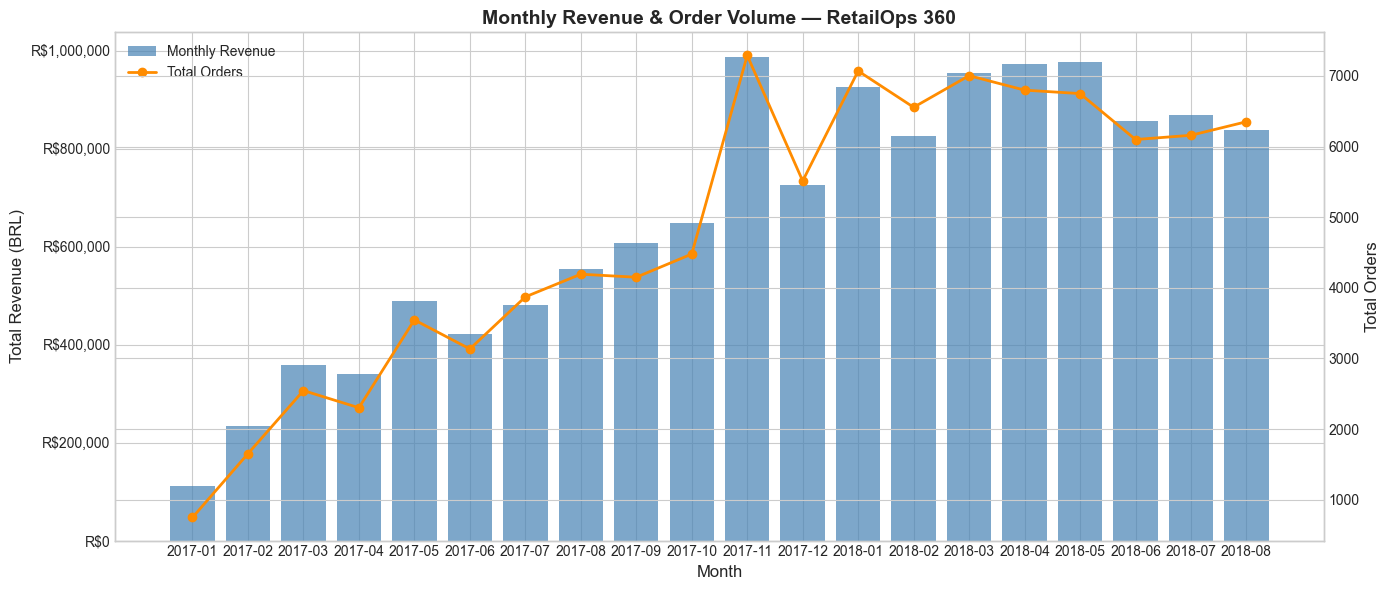

Chart saved successfully


In [5]:
# Aggregate monthly revenue
monthly = (
    master.groupby('order_month')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_revenue=('price', 'sum'),
        avg_order_value=('price', 'mean')
    )
    .reset_index()
)

monthly['order_month_str'] = monthly['order_month'].astype(str)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(monthly['order_month_str'], monthly['total_revenue'],
        color='steelblue', alpha=0.7, label='Monthly Revenue')
ax1.set_ylabel('Total Revenue (BRL)', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(monthly['order_month_str'], monthly['total_orders'],
         color='darkorange', marker='o', linewidth=2, label='Total Orders')
ax2.set_ylabel('Total Orders', fontsize=12)

plt.title('Monthly Revenue & Order Volume — RetailOps 360', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(r'C:\Users\Ali\Downloads\New folder (4)\monthly_revenue_trend.png', dpi=150)
plt.show()
print("Chart saved successfully")

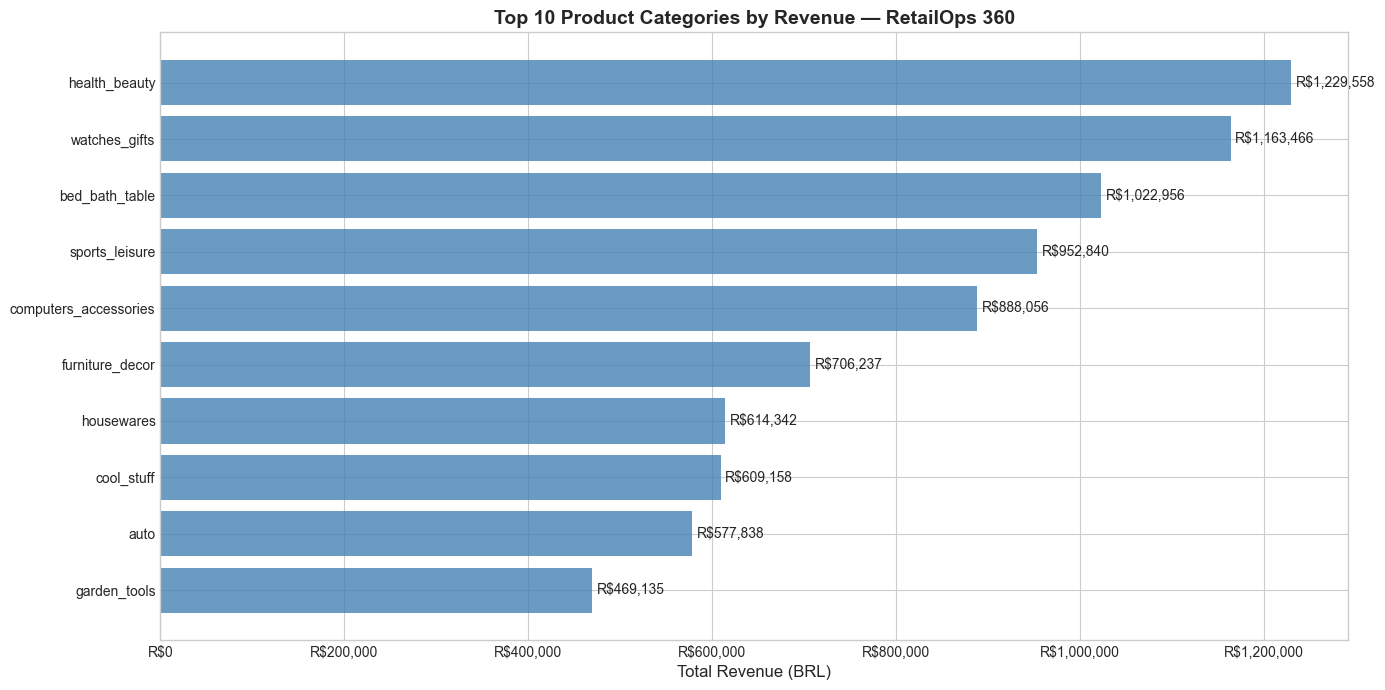

Chart saved successfully


In [6]:
# Merge for category analysis
category_revenue = (
    master.groupby('product_category_name_english')
    .agg(
        total_revenue=('price', 'sum'),
        total_orders=('order_id', 'nunique'),
        avg_price=('price', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
    .head(10)
)

# Plot top 10 categories
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    category_revenue['product_category_name_english'],
    category_revenue['total_revenue'],
    color='steelblue', alpha=0.8
)

# Add value labels on bars
for bar, val in zip(bars, category_revenue['total_revenue']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'R${val:,.0f}', va='center', fontsize=10)

ax.set_xlabel('Total Revenue (BRL)', fontsize=12)
ax.set_title('Top 10 Product Categories by Revenue — RetailOps 360',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(r'C:\Users\Ali\Downloads\New folder (4)\category_revenue.png', dpi=150)
plt.show()
print("Chart saved successfully")

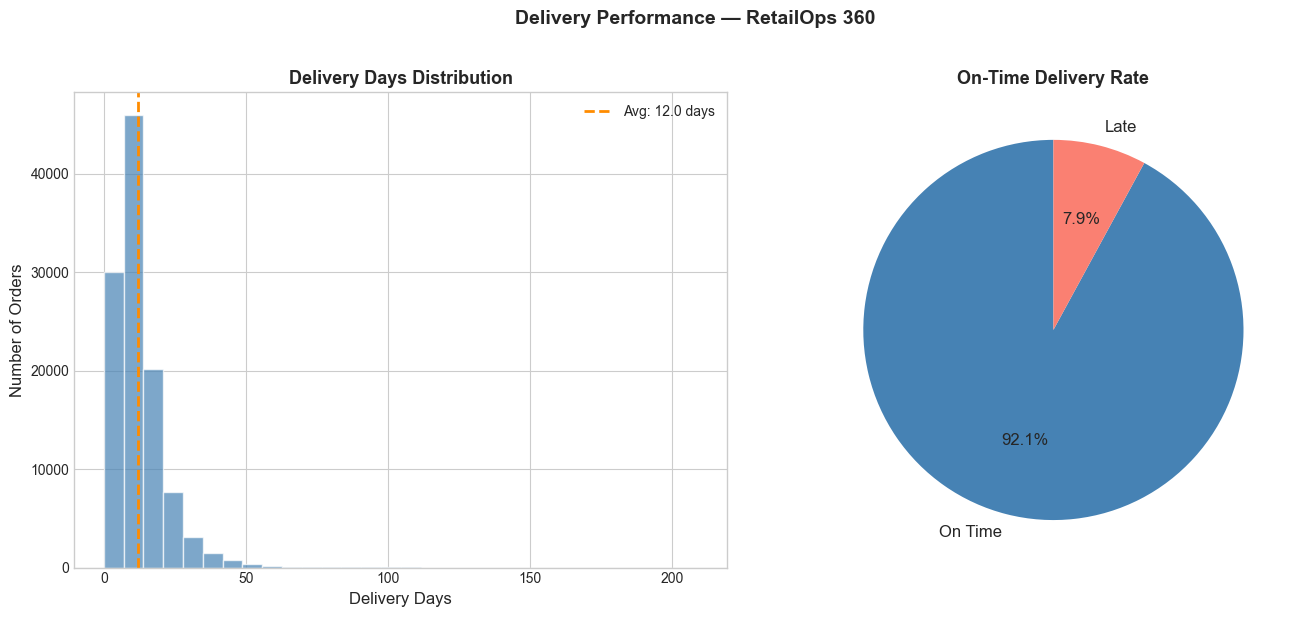

On-time rate: 92.1% | Avg delivery: 12.0 days


In [7]:
# Calculate delivery performance
master['on_time'] = (
    master['order_delivered_customer_date'] <=
    master['order_estimated_delivery_date']
)

on_time_rate = master['on_time'].mean() * 100
avg_delivery = master['delivery_days'].mean()

# Delivery days distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — delivery days histogram
axes[0].hist(
    master['delivery_days'].dropna(),
    bins=30, color='steelblue', alpha=0.7, edgecolor='white'
)
axes[0].axvline(avg_delivery, color='darkorange', linewidth=2,
                linestyle='--', label=f'Avg: {avg_delivery:.1f} days')
axes[0].set_xlabel('Delivery Days', fontsize=12)
axes[0].set_ylabel('Number of Orders', fontsize=12)
axes[0].set_title('Delivery Days Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

# Right — on-time vs late pie chart
axes[1].pie(
    [on_time_rate, 100 - on_time_rate],
    labels=['On Time', 'Late'],
    colors=['steelblue', 'salmon'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('On-Time Delivery Rate', fontsize=13, fontweight='bold')

plt.suptitle('Delivery Performance — RetailOps 360',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Ali\Downloads\New folder (4)\delivery_performance.png', dpi=150)
plt.show()
print(f"On-time rate: {on_time_rate:.1f}% | Avg delivery: {avg_delivery:.1f} days")

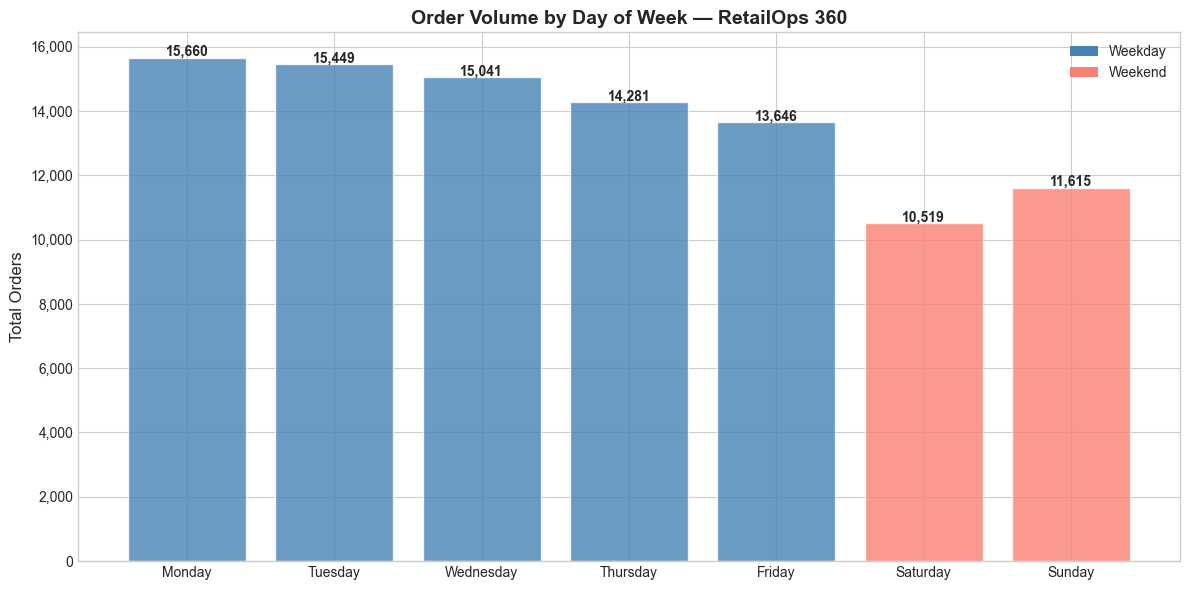

Chart saved successfully


In [8]:
# Order volume by day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

dow = (
    master.groupby('order_dow')
    .agg(total_orders=('order_id', 'nunique'))
    .reindex(dow_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['steelblue' if d not in ['Saturday', 'Sunday']
          else 'salmon' for d in dow['order_dow']]

bars = ax.bar(dow['order_dow'], dow['total_orders'],
              color=colors, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, dow['total_orders']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Total Orders', fontsize=12)
ax.set_title('Order Volume by Day of Week — RetailOps 360',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Weekday'),
                   Patch(facecolor='salmon', label='Weekend')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig(r'C:\Users\Ali\Downloads\New folder (4)\dow_order_patterns.png', dpi=150)
plt.show()
print("Chart saved successfully")